In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")

import matplotlib.pyplot as plt
import numpy as np
import random
import os
import networkx as nx

from src.graphs import StaticGraph, DynamicGraph, IntersectingEdgesGraph, MultiEdgeGraph, DiagonalEdgeGraph
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, SparsePauliOp, Pauli
from scipy.linalg import expm
import itertools

from IPython.display import display

In [2]:

def graph_to_bitstring_edges(graph):
    # Number of nodes in the graph
    num_nodes = len(graph.nodes)

    # Determine how many bits are needed for each node (based on the number of nodes)
    num_bits = len(bin(num_nodes - 1)) - 2  # bin(x) gives '0bxxx', so we subtract 2

    # Create a mapping of node to bit string
    node_to_bitstring = {node: format(node, f'0{num_bits}b') for node in graph.nodes}

    # Convert edges to the new format
    edges_bitstring = {(node_to_bitstring[u], node_to_bitstring[v]) for u, v in graph.edges}

    return edges_bitstring


#g6 = f'./../data/graphs/graph4c.g6'

n_vertex = 2**7

g6 = f'./../data/graphs/graph{n_vertex}c.g6'

graph_edges = []

# Open and read the .g6 file line by line
with open(g6, 'r') as file:
    for line in file:
        g6_string = line.strip()
        try:
            # Convert the graph6 string into a NetworkX graph
            graph = nx.from_graph6_bytes(g6_string.encode('utf-8'))
            
            # Convert the graph edges to bit string format
            bitstring_edges = graph_to_bitstring_edges(graph)
            
            # Output the result
            #print(bitstring_edges)
            graph_edges.append(bitstring_edges)
            #G = StaticGraph(bitstring_edges)
            G = DiagonalEdgeGraph(bitstring_edges)
            # display(G.draw())  
            # display(G.get_qc(simplified=True).draw('mpl'))
        except nx.NetworkXError as e:
            print(f"Error: {e}")

In [3]:
def unitary_to_pauli(U):
    n = int(np.log2(U.shape[0]))
    dim = 2**n
    pauli_strings = []
    coeffs = []
    for pauli_string in [''.join(p) for p in itertools.product('IXYZ', repeat=n)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ U) / dim
        if not np.isclose(coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(coeff)
    return SparsePauliOp(pauli_strings, coeffs)

def construct_time_evolution_matrix(pauli_terms, delta_t):
    matrix = Operator(pauli_terms).data
    exponent = -1j * delta_t * matrix
    return Operator(expm(exponent))

def count_gates_dynamic_walk(edges, T, delta_t):
    G = StaticGraph(edges)
    graph_sequence = [(G, T)]
    dyn_G = DynamicGraph(graph_sequence)
    intersecting_G = IntersectingEdgesGraph(edges)
    graph_sequence = [(graph, delta_t) for graph in intersecting_G.subgraphs]
    dyn_G_approx = DynamicGraph(graph_sequence)
    
    big_qc = QuantumCircuit(G.n_qubits)
    for sq in dyn_G_approx.graph_sequence:
        G = MultiEdgeGraph(sq[0].edges)
        sub_qc = G.get_qc(simplified=True)
        big_qc = big_qc.compose(sub_qc)
    
    # transpiled_qc = min([transpile(big_qc, basis_gates=['cx', 'u3'], optimization_level=3) 
    #                 for _ in range(10)], 
    #                key=lambda c: c.count_ops()['cx'])
    transpiled_qc = transpile(big_qc, basis_gates=['cx', 'u3'], optimization_level=3, seed_transpiler=42)
    gate_counts = transpiled_qc.count_ops()
    return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()

def count_gates_pauli_decomp(edges, delta_t):
    G = StaticGraph(edges)
    pauli_terms = unitary_to_pauli(G.get_adj_mat())
    evo_matrix_from_pauli = construct_time_evolution_matrix(pauli_terms, delta_t)
    
    qc = QuantumCircuit(G.n_qubits)
    qc.unitary(evo_matrix_from_pauli, range(G.n_qubits), label='Evo')
    
    # transpiled_qc = min([transpile(qc, basis_gates=['cx', 'u3'], optimization_level=3) 
    #                 for _ in range(10)], 
    #                key=lambda c: c.count_ops()['cx'])
    transpiled_qc = transpile(qc, basis_gates=['cx', 'u3'], optimization_level=3, seed_transpiler=42)
    gate_counts = transpiled_qc.count_ops()
    return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()


In [4]:
T = 200
delta_t = 0.1

results = []
error_graphs = []

for i, edges in enumerate(graph_edges):
    try:
        dynamic_cx, dynamic_u3, dynamic_depth = count_gates_dynamic_walk(edges, T, delta_t)
        pauli_cx, pauli_u3, pauli_depth = count_gates_pauli_decomp(edges, delta_t)
        
        dynamic_total = dynamic_cx + dynamic_u3
        pauli_total = pauli_cx + pauli_u3
        difference = dynamic_total - pauli_total
        
        results.append({
            'Graph': i,
            'Dynamic': dynamic_total,
            'Pauli': pauli_total,
            'Difference': difference,
            'Edges': edges
        })
        
        ##print(f"Graph {i+1}: Total gates - Dynamic: {dynamic_total}, Pauli: {pauli_total}, Difference: {difference}")
    except Exception as e:
        print(f"Error in Graph {i+1}: {str(e)}")
        print(edges)
        error_graphs.append((i, edges))



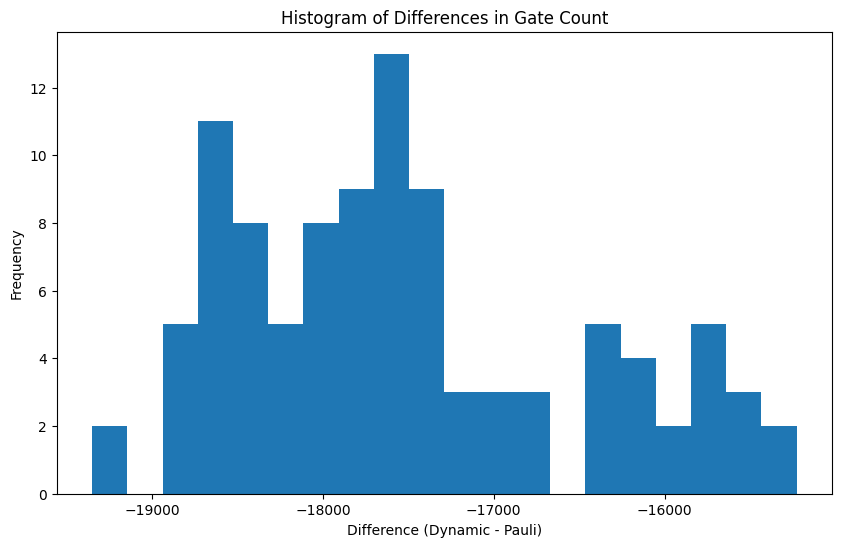

In [5]:
differences = [r['Difference'] for r in results]
plt.figure(figsize=(10, 6))
plt.hist(differences, bins=20)
plt.title('Histogram of Differences in Gate Count')
plt.xlabel('Difference (Dynamic - Pauli)')
plt.ylabel('Frequency')
plt.show()

In [6]:
# Classify graphs
positive_graphs = [r for r in results if r['Difference'] > 0]
negative_graphs = [r for r in results if r['Difference'] < 0]
zero_graphs = [r for r in results if r['Difference'] == 0]

# Function to save graphs in G6 format
def save_graphs(graphs, filename):
    with open(filename, 'w') as f:
        for graph in graphs:
            G = nx.Graph(graph['Edges'])
            g6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
            f.write(f"{g6_string}\n")

# Save classified graphs
save_graphs(positive_graphs, f'../data/graphs/positive_{n_vertex}cgraphs.g6')
save_graphs(negative_graphs, f'../data/graphs/negative_{n_vertex}cgraphs.g6')
save_graphs(zero_graphs, f'../data/graphs/zero_{n_vertex}cgraphs.g6')

# Save error graphs
with open(f'../data/graphs/error_{n_vertex}cgraphs.g6', 'w') as f:
    for _, edges in error_graphs:
        G = nx.Graph(edges)
        g6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
        f.write(f"{g6_string}\n")

In [7]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

def count_graphs(filename):
    count = 0
    with open(filename, 'r') as file:
        for line in file:
            if line.strip():
                count += 1
    return count

def visualize_random_graphs(filename, num_graphs=5):
    graph_edges = []
    
    with open(filename, 'r') as file:
        g6_strings = file.readlines()
    
    if len(g6_strings) < num_graphs:
        num_graphs = len(g6_strings)
    
    random_g6_strings = random.sample(g6_strings, num_graphs)
    
    for g6_string in random_g6_strings:
        try:
            graph = nx.from_graph6_bytes(g6_string.strip().encode('utf-8'))
            bitstring_edges = graph_to_bitstring_edges(graph)
            G = StaticGraph(bitstring_edges)
            display(G.draw())
        except nx.NetworkXError as e:
            print(f"Error: {e}")


Analyzing graphs from positive_128cgraphs.g6
Number of graphs: 0
Percentage of original: 0.00%
Visualizing 5 random graphs:

Analyzing graphs from negative_128cgraphs.g6
Number of graphs: 100
Percentage of original: 100.00%
Visualizing 5 random graphs:


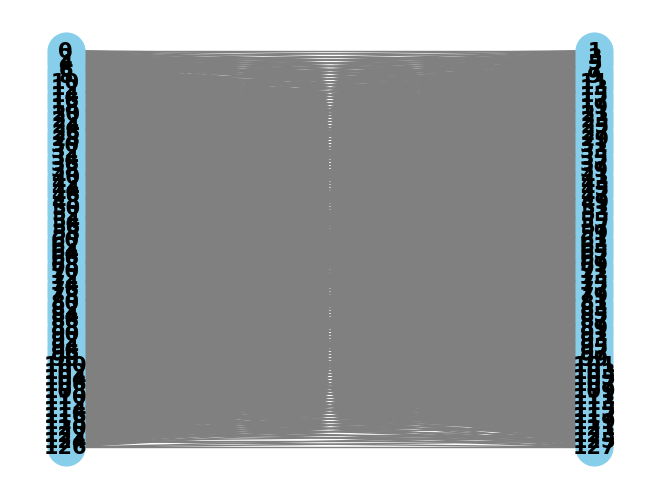

None

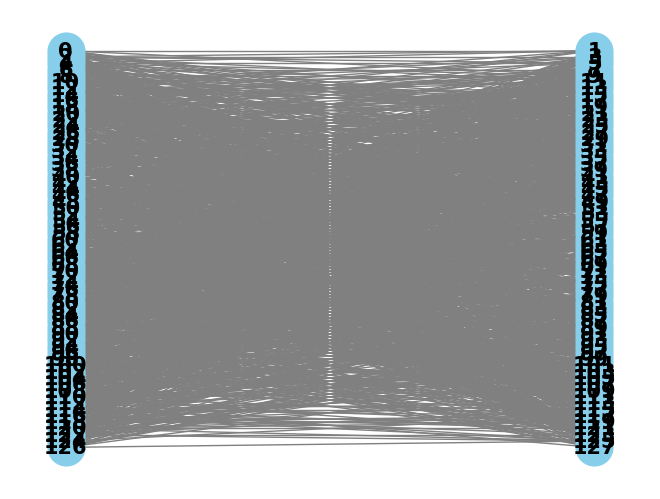

None

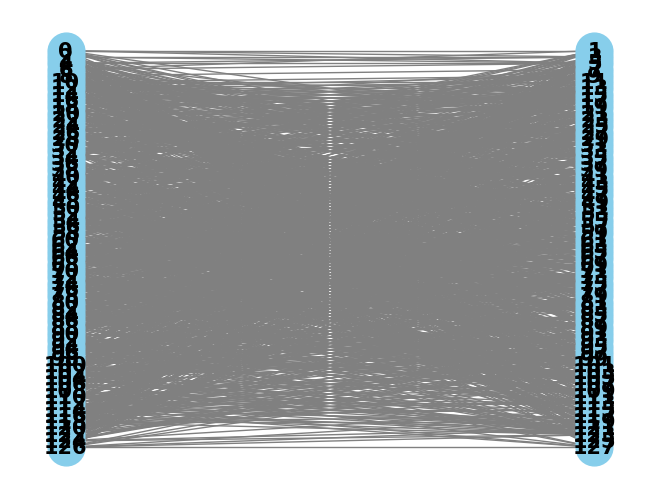

None

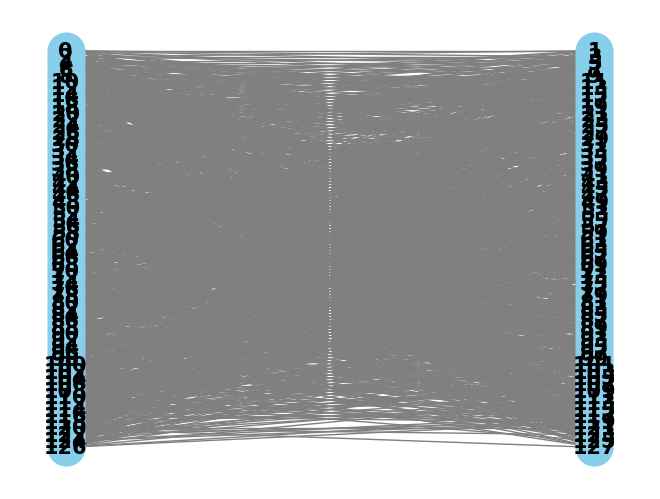

None

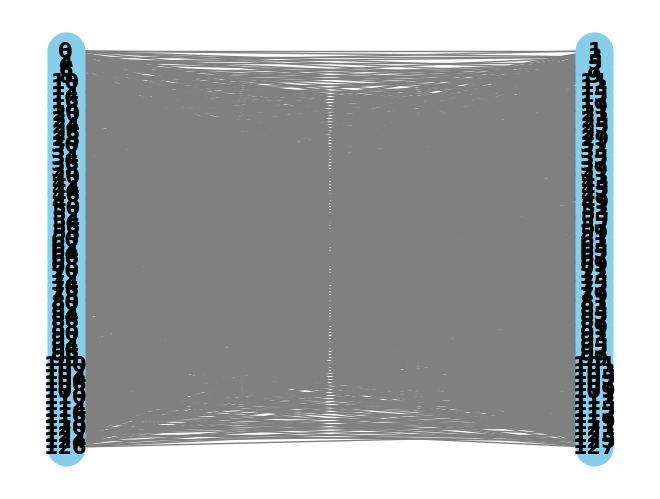

None


Analyzing graphs from zero_128cgraphs.g6
Number of graphs: 0
Percentage of original: 0.00%
Visualizing 5 random graphs:

Analyzing graphs from error_128cgraphs.g6
Number of graphs: 0
Percentage of original: 0.00%
Visualizing 5 random graphs:


In [8]:
# Count graphs in the original file
original_file = f'./../data/graphs/graph{n_vertex}c.g6'
original_count = count_graphs(original_file)

# Visualize and count graphs for each file
files = [f'positive_{n_vertex}cgraphs.g6', f'negative_{n_vertex}cgraphs.g6', f'zero_{n_vertex}cgraphs.g6', f'error_{n_vertex}cgraphs.g6']
for filename in files:
    full_path = os.path.join('../data/graphs', filename)
    print(f"\nAnalyzing graphs from {filename}")
    
    # Count graphs
    graph_count = count_graphs(full_path)
    percentage = (graph_count / original_count) * 100
    
    print(f"Number of graphs: {graph_count}")
    print(f"Percentage of original: {percentage:.2f}%")
    
    # Visualize random graphs
    print("Visualizing 5 random graphs:")
    visualize_random_graphs(full_path)

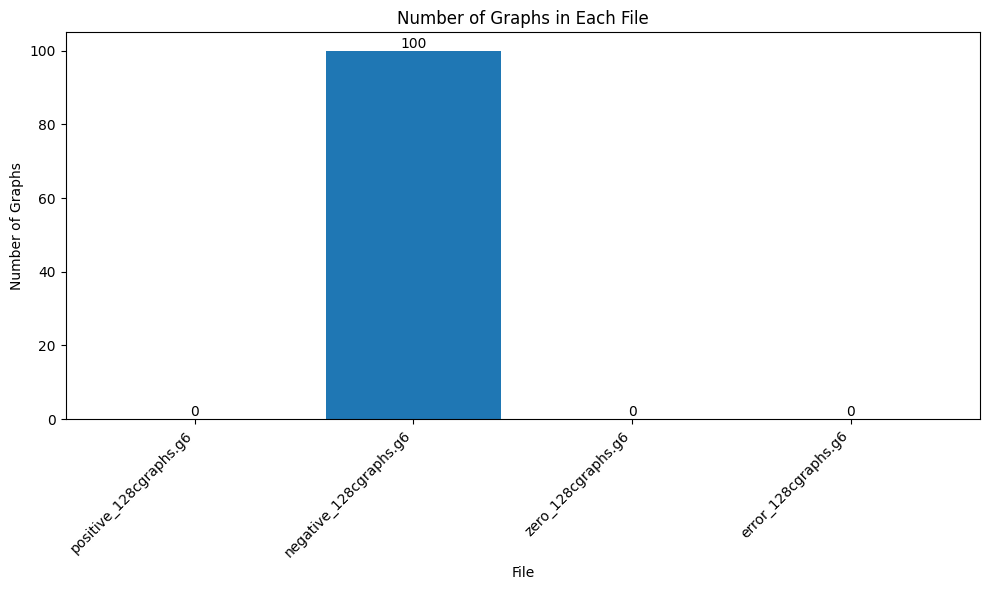

In [9]:
# Create a bar plot of graph counts
counts = [count_graphs(os.path.join('../data/graphs', f)) for f in files]
plt.figure(figsize=(10, 6))
plt.bar(files, counts)
plt.title('Number of Graphs in Each File')
plt.xlabel('File')
plt.ylabel('Number of Graphs')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

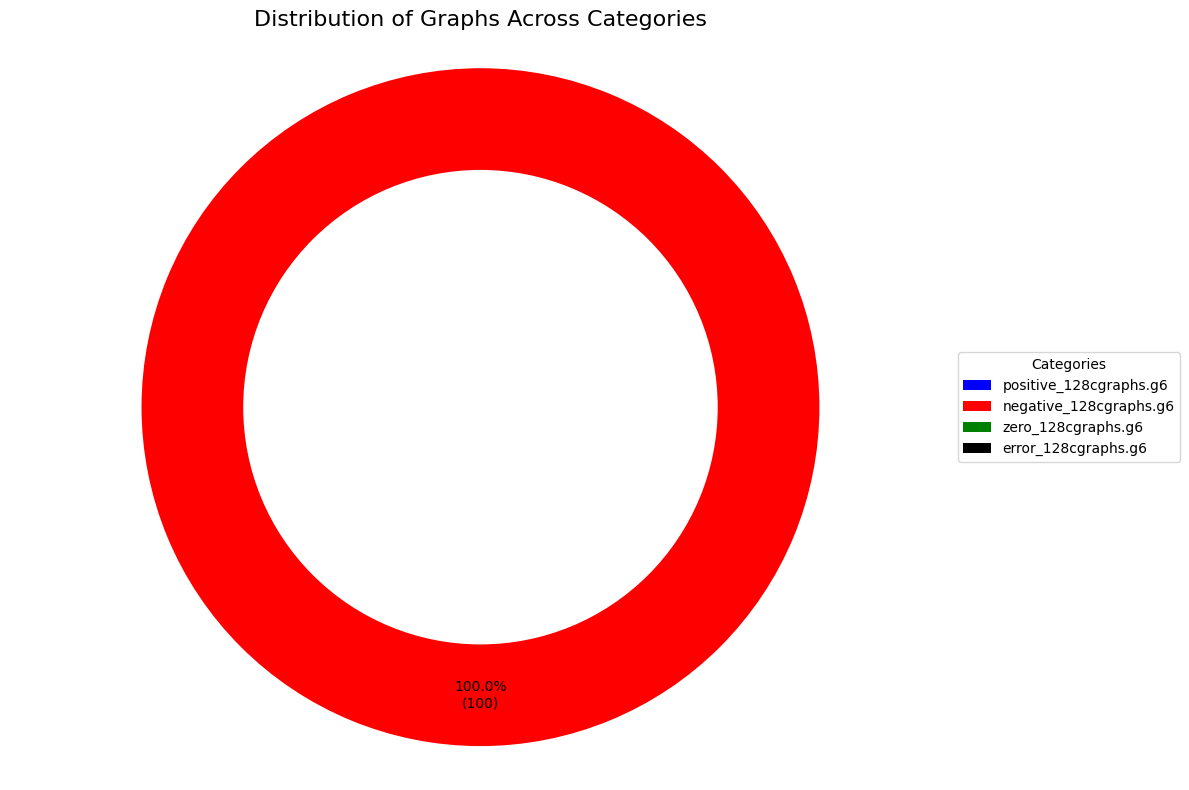

In [10]:
# Create a pie chart of percentages
percentages = [(count / original_count) * 100 for count in counts]
labels = [f.replace('_graphs.g6', '') for f in files]  # Simplify labels

plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'black']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val:d})' if pct > 1 else ''
    return my_autopct

wedges, texts, autotexts = plt.pie(percentages, colors=colors, 
                                   autopct=make_autopct(counts),
                                   startangle=90, pctdistance=0.85)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Graphs Across Categories', fontsize=16)
plt.axis('equal')

# Add legend
plt.legend(wedges, labels,
           title="Categories",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()